In [1]:
%load_ext water_quality.magics

In [2]:
from water_quality.logs import setup_logging
log = setup_logging()

In [3]:
import xarray as xr
from datacube import Datacube
# Useful later the year to plot for
year = "2023"

# Load the instrument data generated using the prototyping WP1.2 notebooks
wp_12_data_xr = xr.open_dataset("fai_ndvi_clear_water.nc", engine='h5netcdf')
wp_12_data_xr

2026-02-21 19:39:55,678 numexpr.utils [INFO]: NumExpr defaulting to 4 threads.


<xarray.Dataset> Size: 16MB
Dimensions:       (time: 25, y: 170, x: 76)
Coordinates:
  * time          (time) datetime64[ns] 200B 2000-07-01T23:59:59.999999 ... 2...
  * y             (y) float64 1kB 5.731e+04 5.753e+04 ... 9.427e+04 9.449e+04
  * x             (x) float64 608B 3.473e+06 3.474e+06 ... 3.49e+06 3.49e+06
    spatial_ref   int32 4B ...
Data variables:
    msi_agm_ndvi  (time, y, x) float32 1MB ...
    oli_agm_ndvi  (time, y, x) float64 3MB ...
    tm_agm_ndvi   (time, y, x) float32 1MB ...
    agm_ndvi      (time, y, x) float64 3MB ...
    msi_agm_fai   (time, y, x) float32 1MB ...
    oli_agm_fai   (time, y, x) float64 3MB ...
    tm_agm_fai    (time, y, x) float32 1MB ...
    agm_fai       (time, y, x) float64 3MB ...
    clearwater    (time, y, x) bool 323kB ...
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

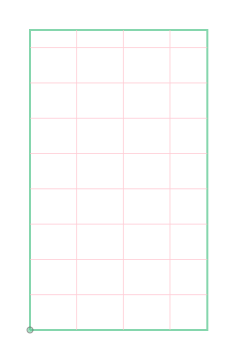

In [4]:
tile_geobox = wp_12_data_xr.odc.geobox
tile_geobox

In [5]:
import rioxarray

wq_ds = {}
wq_ds["clear_water"] = rioxarray.open_rasterio("test/wq_annual/1-0-0/x217/y077/2023--P1Y/wq_annual_x217y077_2023--P1Y_clear_water.tif").squeeze()
wq_ds["clear_water"]

<xarray.DataArray (y: 170, x: 76)> Size: 52kB
[12920 values with dtype=float32]
Coordinates:
  * y            (y) float64 1kB 5.731e+04 5.753e+04 ... 9.427e+04 9.449e+04
  * x            (x) float64 608B 3.473e+06 3.474e+06 ... 3.49e+06 3.49e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    offsets:          0
    product_name:     wq_annual
    product_version:  1.0.0
    scales:           1
    _FillValue:       nan
    scale_factor:     1.0
    add_offset:       0.0

In [6]:
def required_counts(da_):
    valid_pixels = da_.count().item()
    total_pixels = da_.size
    return f"{valid_pixels} valid_pixels \n {total_pixels} total pixels"

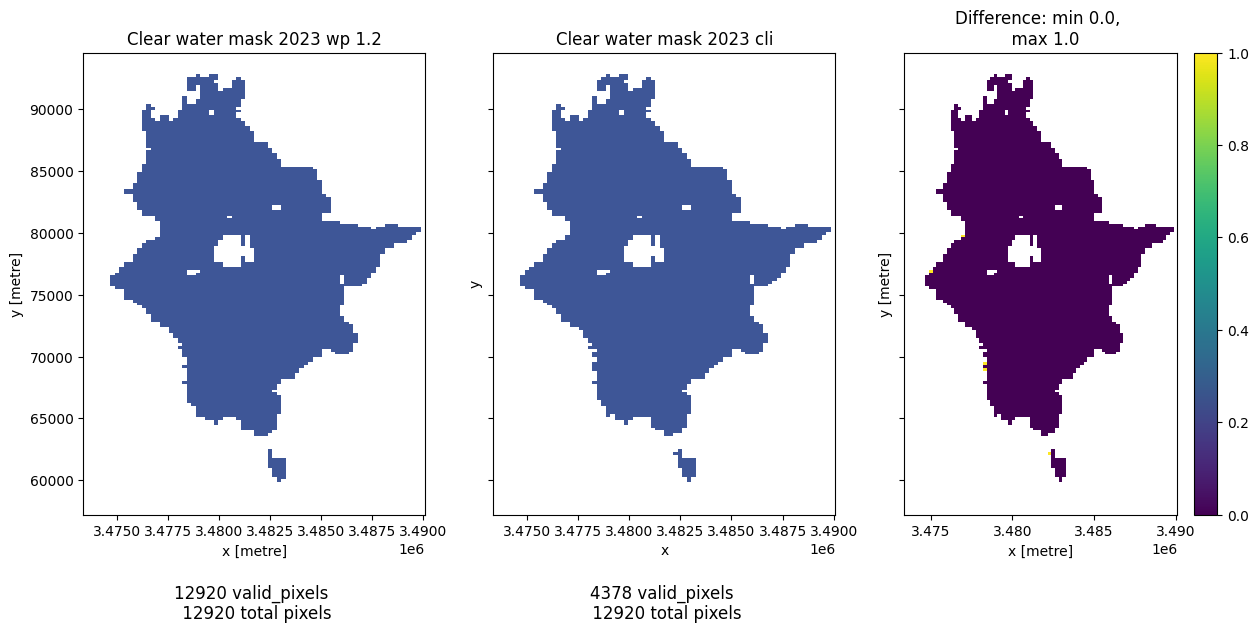

In [7]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# fig, ax = plt.subplots(figsize=(5,6))
fig, ax = plt.subplots(1, 3, sharey=True, figsize=(15,6))
cmap = mcolors.ListedColormap(["none", "#3E5697"])

ref_da = wp_12_data_xr.sel(time=year)["clearwater"]
da = wq_ds["clear_water"]

diff = np.abs(ref_da - da)
min_diff = diff.min().item()
max_diff = diff.max().item() 

ref_da.plot(
    ax=ax[0],
    cmap=cmap,
    vmin=0,
    vmax=1,
    add_colorbar=False
)
ax[0].text(0.5, -0.15, required_counts(ref_da), 
        transform=ax[0].transAxes, 
        ha='center', va='top', fontsize=12)
ax[0].set_title(f"Clear water mask {year} wp 1.2")

da.plot(
    ax=ax[1],
    cmap=cmap,
    vmin=0,
    vmax=1,
    add_colorbar=False
)
ax[1].text(0.5, -0.15, required_counts(da), 
        transform=ax[1].transAxes, 
        ha='center', va='top', fontsize=12)
ax[1].set_title(f"Clear water mask {year} cli")

diff.plot(ax=ax[2])
ax[2].set_title(f"Difference: min {min_diff}, \n  max {max_diff}")

plt.savefig('clear_water_mask_comparison_plots.png', dpi=200)

plt.show()